<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/week2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# WEEK 2 — Tier 1: Attention U-Net Baseline
# ============================================================
# Purpose: sanity-check the data pipeline, training loop, and
# evaluation code (Dice/IoU/Precision/Recall/Specificity/HD95)
# on a simple, well-documented architecture before building
# D-SAS's custom modules (SSBG, AAS, SFH) in Week 3+.
#
# Dataset: BUSI, deduplicated (527 images), split 368/78/81
# Result:  Dice 0.7215 | IoU 0.5698 | Precision 0.7999
#          Recall 0.6629 | Specificity 0.9780
# ============================================================

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, csv, json, hashlib, random
from collections import defaultdict
from itertools import combinations

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy.ndimage import distance_transform_edt, binary_erosion

print("CUDA available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "Switch runtime to GPU: Runtime -> Change runtime type -> GPU"

random.seed(42)

RAW_ROOT = '/content/data/Dataset_BUSI_with_GT'
CLASSES = ['benign', 'malignant']
NEAR_DUP_THRESHOLD = 5
IMG_SIZE = 256
FINAL_DIR = '/content/drive/MyDrive/BUSI_Dataset'
PROJECT_DIR = f'{FINAL_DIR}/tier1_attention_unet'
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/logs', exist_ok=True)

Mounted at /content/drive
CUDA available: True


In [3]:
if not os.path.exists(RAW_ROOT):
    from google.colab import userdata
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
    os.makedirs("/content/data", exist_ok=True)
    os.system("pip install -q -U kaggle")
    os.system(
        "kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset "
        "-p /content/data --unzip"
    )
print("Raw dataset present:", os.path.exists(RAW_ROOT))

Raw dataset present: True


In [4]:
try:
    import imagehash
except ImportError:
    os.system("pip install -q ImageHash")
    import imagehash

def collect_images(root, classes):
    records = []
    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)
        images = [f for f in all_files
                  if f.lower().endswith(('.png', '.jpg', '.jpeg')) and '_mask' not in f.lower()]
        for image_file in images:
            base_name = os.path.splitext(image_file)[0]
            masks = [f for f in all_files if f.startswith(base_name + '_mask')]
            records.append({
                'class': cls, 'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [os.path.join(folder, m) for m in masks],
            })
    return records

def md5_hash(filepath):
    md5 = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)
    return md5.hexdigest()

def phash(filepath):
    return imagehash.phash(Image.open(filepath).convert('L'))

def find_exact_duplicate_groups(records):
    groups = defaultdict(list)
    for r in records:
        groups[md5_hash(r['image_path'])].append(r)
    return [g for g in groups.values() if len(g) > 1]

def find_near_duplicate_pairs(records, threshold):
    hashes = [(r, phash(r['image_path'])) for r in records]
    pairs = []
    for (r_a, h_a), (r_b, h_b) in combinations(hashes, 2):
        if h_a - h_b <= threshold:
            pairs.append((r_a, r_b, h_a - h_b))
    return pairs

class UnionFind:
    def __init__(self, items):
        self.parent = {id(item): item for item in items}
    def find(self, item):
        pid = id(item)
        while self.parent[pid] is not item:
            item = self.parent[pid]; pid = id(item)
        return item
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra is not rb:
            self.parent[id(ra)] = rb

def group_near_duplicates(records, pairs):
    uf = UnionFind(records)
    for r_a, r_b, _ in pairs:
        uf.union(r_a, r_b)
    groups = defaultdict(list)
    for r in records:
        groups[id(uf.find(r))].append(r)
    return [g for g in groups.values() if len(g) > 1]

print("Collecting image records...")
records = collect_images(RAW_ROOT, CLASSES)
print(f"Total benign+malignant images: {len(records)}")

exact_groups = find_exact_duplicate_groups(records)
print(f"Exact duplicate groups: {len(exact_groups)}")

near_pairs = find_near_duplicate_pairs(records, NEAR_DUP_THRESHOLD)
near_groups = group_near_duplicates(records, near_pairs)
print(f"Near-duplicate groups: {len(near_groups)}")

same_class_groups, cross_class_groups = [], []
for g in near_groups:
    (cross_class_groups if len({r['class'] for r in g}) > 1 else same_class_groups).append(g)
print(f"Same-class groups: {len(same_class_groups)} | Cross-class conflicts: {len(cross_class_groups)}")

excluded_paths = {r['image_path'] for g in cross_class_groups for r in g}
kept_records, seen_paths = [], set()
for g in same_class_groups:
    kept_records.append(g[0]); seen_paths.add(g[0]['image_path'])
    for r in g[1:]:
        seen_paths.add(r['image_path'])
for r in records:
    if r['image_path'] not in excluded_paths and r['image_path'] not in seen_paths:
        kept_records.append(r)

print(f"\nFinal deduplicated dataset: {len(kept_records)} images (removed {len(records) - len(kept_records)})")
for cls in CLASSES:
    n = sum(1 for r in kept_records if r['class'] == cls)
    print(f"  {cls}: {n}")

Total benign+malignant images: 647
Exact duplicate groups: 1
Near-duplicate groups: 98
Same-class groups: 92 | Cross-class conflicts: 6

Final deduplicated dataset: 527 images (removed 120)
  benign: 334
  malignant: 193


In [5]:
def stratified_split(records, classes, ratios=(0.70, 0.15, 0.15)):
    train, val, test = [], [], []
    for cls in classes:
        cls_records = [r for r in records if r['class'] == cls]
        random.shuffle(cls_records)
        n = len(cls_records)
        n_train, n_val = int(n * ratios[0]), int(n * ratios[1])
        train.extend(cls_records[:n_train])
        val.extend(cls_records[n_train:n_train + n_val])
        test.extend(cls_records[n_train + n_val:])
    random.shuffle(train); random.shuffle(val); random.shuffle(test)
    return train, val, test

def save_split_csv(path, records):
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['class', 'image_path', 'mask_paths'])
        for r in records:
            writer.writerow([r['class'], r['image_path'], '|'.join(r['mask_paths'])])

train_records, val_records, test_records = stratified_split(kept_records, CLASSES)
print(f"Split — train: {len(train_records)}, val: {len(val_records)}, test: {len(test_records)}")

save_split_csv(f'{FINAL_DIR}/train.csv', train_records)
save_split_csv(f'{FINAL_DIR}/val.csv', val_records)
save_split_csv(f'{FINAL_DIR}/test.csv', test_records)
print(f"Splits saved to {FINAL_DIR}")

Split — train: 368, val: 78, test: 81
Splits saved to /content/drive/MyDrive/BUSI_Dataset


In [6]:
def get_train_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_eval_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class BUSISegmentationDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.records = []
        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                mask_paths = row['mask_paths'].split('|') if row['mask_paths'] else []
                self.records.append({'class': row['class'], 'image_path': row['image_path'], 'mask_paths': mask_paths})
        self.transform = transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        record = self.records[idx]
        image = np.array(Image.open(record['image_path']).convert('RGB'))
        mask = None
        for mp in record['mask_paths']:
            m = (np.array(Image.open(mp).convert('L')) > 0).astype(np.uint8)
            mask = m if mask is None else np.maximum(mask, m)
        if mask is None:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask'].unsqueeze(0).float()
        return {'image': image, 'mask': mask, 'class': record['class']}

def get_dataloaders(splits_dir, batch_size=16, img_size=IMG_SIZE, num_workers=2):
    train_ds = BUSISegmentationDataset(f'{splits_dir}/train.csv', transform=get_train_transform(img_size))
    val_ds = BUSISegmentationDataset(f'{splits_dir}/val.csv', transform=get_eval_transform(img_size))
    test_ds = BUSISegmentationDataset(f'{splits_dir}/test.csv', transform=get_eval_transform(img_size))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders(FINAL_DIR)
_batch = next(iter(train_loader))
print("Sanity check — Image shape:", _batch["image"].shape, "| Mask shape:", _batch["mask"].shape)

Train: 368 | Val: 78 | Test: 81
Sanity check — Image shape: torch.Size([16, 3, 256, 256]) | Mask shape: torch.Size([16, 1, 256, 256])


In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

class AttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.enc1 = ConvBlock(in_ch, features[0])
        self.enc2 = ConvBlock(features[0], features[1])
        self.enc3 = ConvBlock(features[1], features[2])
        self.enc4 = ConvBlock(features[2], features[3])
        self.bottleneck = ConvBlock(features[3], features[3] * 2)
        self.up4 = nn.ConvTranspose2d(features[3] * 2, features[3], 2, stride=2)
        self.att4 = AttentionGate(features[3], features[3], features[3] // 2)
        self.dec4 = ConvBlock(features[3] * 2, features[3])
        self.up3 = nn.ConvTranspose2d(features[3], features[2], 2, stride=2)
        self.att3 = AttentionGate(features[2], features[2], features[2] // 2)
        self.dec3 = ConvBlock(features[2] * 2, features[2])
        self.up2 = nn.ConvTranspose2d(features[2], features[1], 2, stride=2)
        self.att2 = AttentionGate(features[1], features[1], features[1] // 2)
        self.dec2 = ConvBlock(features[1] * 2, features[1])
        self.up1 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)
        self.att1 = AttentionGate(features[0], features[0], features[0] // 2)
        self.dec1 = ConvBlock(features[0] * 2, features[0])
        self.final = nn.Conv2d(features[0], out_ch, kernel_size=1)
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b); d4 = self.dec4(torch.cat([d4, self.att4(g=d4, x=e4)], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, self.att3(g=d3, x=e3)], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, self.att2(g=d2, x=e2)], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, self.att1(g=d1, x=e1)], dim=1))
        return self.final(d1)

print("Model defined")

Model defined


In [8]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, pred_logits, target):
        bce_loss = self.bce(pred_logits, target)
        pred = torch.sigmoid(pred_logits)
        pf, tf = pred.view(-1), target.view(-1)
        intersection = (pf * tf).sum()
        dice_loss = 1 - (2 * intersection + self.smooth) / (pf.sum() + tf.sum() + self.smooth)
        return bce_loss + dice_loss

def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum(); fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum(); tn = ((1 - pred) * (1 - target)).sum()
    dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
    iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    specificity = (tn + 1e-6) / (tn + fp + 1e-6)
    return {"dice": dice.item(), "iou": iou.item(), "precision": precision.item(), "recall": recall.item(), "specificity": specificity.item()}

def compute_hd95_single(pred_mask, gt_mask):
    if not pred_mask.any() or not gt_mask.any():
        return None
    pred_border = pred_mask ^ binary_erosion(pred_mask)
    gt_border = gt_mask ^ binary_erosion(gt_mask)
    dt_gt = distance_transform_edt(~gt_border)
    dt_pred = distance_transform_edt(~pred_border)
    d_pred_to_gt = dt_gt[pred_border]
    d_gt_to_pred = dt_pred[gt_border]
    return max(np.percentile(d_pred_to_gt, 95), np.percentile(d_gt_to_pred, 95))

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in loader:
        images, masks = batch["image"].to(device), batch["mask"].to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_metrics, hd95_values = 0, [], []
    with torch.no_grad():
        for batch in loader:
            images, masks = batch["image"].to(device), batch["mask"].to(device)
            preds = model(images)
            total_loss += loss_fn(preds, masks).item()
            all_metrics.append(compute_metrics(preds, masks))
            pred_bin = (torch.sigmoid(preds) > 0.5).cpu().numpy().astype(bool)
            gt_bin = masks.cpu().numpy().astype(bool)
            for i in range(pred_bin.shape[0]):
                hd = compute_hd95_single(pred_bin[i, 0], gt_bin[i, 0])
                if hd is not None:
                    hd95_values.append(hd)
    avg = {k: sum(m[k] for m in all_metrics) / len(all_metrics) for k in all_metrics[0]}
    avg['hd95_mean'] = float(np.mean(hd95_values)) if hd95_values else float('nan')
    avg['hd95_median'] = float(np.median(hd95_values)) if hd95_values else float('nan')
    avg['hd95_valid_count'] = len(hd95_values)
    return total_loss / len(loader), avg

print("Loss, metrics, train/validate functions defined")

Loss, metrics, train/validate functions defined


In [9]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("set_seed() defined")

set_seed() defined


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

set_seed(42)
model = AttentionUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = DiceBCELoss()

NUM_EPOCHS, PATIENCE = 50, 10
best_val_dice, epochs_no_improve = 0.0, 0
checkpoint_path = f'{PROJECT_DIR}/checkpoints/attention_unet_best.pth'
history = []

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_metrics = validate(model, val_loader, loss_fn, device)
    history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, **val_metrics})
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
          f"| val_dice: {val_metrics['dice']:.4f} | val_iou: {val_metrics['iou']:.4f} | {time.time()-start:.1f}s")
    if val_metrics['dice'] > best_val_dice:
        best_val_dice, epochs_no_improve = val_metrics['dice'], 0
        torch.save(model.state_dict(), checkpoint_path)
        print("  -> new best, checkpoint saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

pd.DataFrame(history).to_csv(f'{PROJECT_DIR}/logs/training_history.csv', index=False)
print(f"\nTraining complete. Best val Dice: {best_val_dice:.4f}")

Using device: cuda
Epoch 1/50 | train_loss: 1.3116 | val_loss: 1.3747 | val_dice: 0.0297 | val_iou: 0.0152 | 24.9s
  -> new best, checkpoint saved
Epoch 2/50 | train_loss: 1.1008 | val_loss: 1.3876 | val_dice: 0.4545 | val_iou: 0.2951 | 25.3s
  -> new best, checkpoint saved
Epoch 3/50 | train_loss: 1.0163 | val_loss: 0.9379 | val_dice: 0.6307 | val_iou: 0.4639 | 25.6s
  -> new best, checkpoint saved
Epoch 4/50 | train_loss: 0.9663 | val_loss: 0.9313 | val_dice: 0.6289 | val_iou: 0.4603 | 25.7s
Epoch 5/50 | train_loss: 0.9263 | val_loss: 0.9333 | val_dice: 0.5834 | val_iou: 0.4148 | 25.7s
Epoch 6/50 | train_loss: 0.9028 | val_loss: 1.0346 | val_dice: 0.5439 | val_iou: 0.3753 | 28.4s
Epoch 7/50 | train_loss: 0.8787 | val_loss: 1.1639 | val_dice: 0.5224 | val_iou: 0.3556 | 26.8s
Epoch 8/50 | train_loss: 0.8726 | val_loss: 0.8763 | val_dice: 0.6422 | val_iou: 0.4742 | 26.0s
  -> new best, checkpoint saved
Epoch 9/50 | train_loss: 0.8461 | val_loss: 0.9567 | val_dice: 0.5588 | val_iou: 0.38

In [44]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

test_loss, test_metrics = validate(model, test_loader, loss_fn, device)
print("\nTest set results (Tier 1 — Attention U-Net baseline):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

results_summary = {'model': 'Attention U-Net (Tier 1)',
                    'dataset': f'BUSI ({len(kept_records)} images, deduplicated, 70/15/15 split)',
                    **test_metrics}
with open(f'{PROJECT_DIR}/logs/test_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("\nSaved test_results.json")

RuntimeError: Error(s) in loading state_dict for AttentionUNet:
	Missing key(s) in state_dict: "enc1.block.0.weight", "enc1.block.0.bias", "enc1.block.1.weight", "enc1.block.1.bias", "enc1.block.1.running_mean", "enc1.block.1.running_var", "enc1.block.3.weight", "enc1.block.3.bias", "enc1.block.4.weight", "enc1.block.4.bias", "enc1.block.4.running_mean", "enc1.block.4.running_var", "enc2.block.0.weight", "enc2.block.0.bias", "enc2.block.1.weight", "enc2.block.1.bias", "enc2.block.1.running_mean", "enc2.block.1.running_var", "enc2.block.3.weight", "enc2.block.3.bias", "enc2.block.4.weight", "enc2.block.4.bias", "enc2.block.4.running_mean", "enc2.block.4.running_var", "enc3.block.0.weight", "enc3.block.0.bias", "enc3.block.1.weight", "enc3.block.1.bias", "enc3.block.1.running_mean", "enc3.block.1.running_var", "enc3.block.3.weight", "enc3.block.3.bias", "enc3.block.4.weight", "enc3.block.4.bias", "enc3.block.4.running_mean", "enc3.block.4.running_var", "enc4.block.0.weight", "enc4.block.

In [ ]:
FINAL_DIR = '/content/drive/MyDrive/BUSI_Dataset'
train_records = pd.read_csv(f'{FINAL_DIR}/train.csv')
val_records = pd.read_csv(f'{FINAL_DIR}/val.csv')
test_records = pd.read_csv(f'{FINAL_DIR}/test.csv')

In [ ]:
model.eval()
batch = next(iter(test_loader))
images, masks = batch["image"].to(device), batch["mask"].to(device)
with torch.no_grad():
    preds = torch.sigmoid(model(images)) > 0.5

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
for i in range(4):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Image — {batch['class'][i]}"); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt, cmap='gray'); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title("Prediction"); axes[i, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/logs/sample_predictions.png', dpi=120)
plt.show()

In [14]:
# ============================================================
# WEEK 3 — D-SAS Tier 2: ResNet101 Backbone + SSBG
# ============================================================

In [15]:
import torchvision.models as models

resnet = models.resnet101(weights='IMAGENET1K_V2')
print(resnet)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 93.2MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
x = torch.randn(1, 3, 256, 256)
x = resnet.maxpool(resnet.relu(resnet.bn1(resnet.conv1(x))))
print("after stem:", x.shape)          # expect [1, 64, 64, 64]

x1 = resnet.layer1(x)
print("layer1:", x1.shape)             # expect [1, 256, 64, 64]  <- 1/4 resolution

x2 = resnet.layer2(x1)
print("layer2:", x2.shape)             # expect [1, 512, 32, 32]

x3 = resnet.layer3(x2)
print("layer3:", x3.shape)             # expect [1, 1024, 16, 16]

x4 = resnet.layer4(x3)
print("layer4:", x4.shape)             # expect [1, 2048, 8, 8]

after stem: torch.Size([1, 64, 64, 64])
layer1: torch.Size([1, 256, 64, 64])
layer2: torch.Size([1, 512, 32, 32])
layer3: torch.Size([1, 1024, 16, 16])
layer4: torch.Size([1, 2048, 8, 8])


In [17]:
def modify_layer4_dilation(resnet):
    for name, module in resnet.layer4.named_modules():
        if isinstance(module, nn.Conv2d) and module.stride == (2, 2):
            module.stride = (1, 1)
            if module.kernel_size == (3, 3):
                # main-path conv: use dilation to preserve receptive field
                module.dilation = (2, 2)
                module.padding = (2, 2)
            # else: 1x1 downsample/shortcut conv — only fix stride,
            # leave padding at 0 (dilation has no effect on a 1x1 kernel anyway)
    return resnet

# Reload a fresh ResNet101 — the previous one is already incorrectly mutated
resnet = models.resnet101(weights='IMAGENET1K_V2')
resnet = modify_layer4_dilation(resnet)

x4 = resnet.layer4(x3)
print("layer4 after fix:", x4.shape)   # expect [1, 2048, 16, 16]

layer4 after fix: torch.Size([1, 2048, 16, 16])


In [18]:
class D_SAS_Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet101(weights='IMAGENET1K_V2')
        resnet = modify_layer4_dilation(resnet)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

    def forward(self, x):
        x = self.stem(x)
        f_low = self.layer1(x)      # [B, 256, H/4, W/4]
        x2 = self.layer2(f_low)
        x3 = self.layer3(x2)
        f_high = self.layer4(x3)    # [B, 2048, H/16, W/16]
        return f_low, f_high

backbone = D_SAS_Backbone().to(device)
f_low, f_high = backbone(torch.randn(2, 3, 256, 256).to(device))
print("F_low:", f_low.shape)   # expect [2, 256, 64, 64]
print("F_high:", f_high.shape) # expect [2, 2048, 16, 16]

F_low: torch.Size([2, 256, 64, 64])
F_high: torch.Size([2, 2048, 16, 16])


In [19]:
class ChannelReduce(nn.Module):
    def __init__(self, in_ch, out_ch=256):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

reduce_low = ChannelReduce(256, 256).to(device)
reduce_high = ChannelReduce(2048, 256).to(device)

f_low_reduced = reduce_low(f_low)
f_high_reduced = reduce_high(f_high)
print(f_low_reduced.shape, f_high_reduced.shape)  # expect [2,256,64,64] and [2,256,16,16]

torch.Size([2, 256, 64, 64]) torch.Size([2, 256, 16, 16])


In [20]:
class SSBG(nn.Module):
    def __init__(self, ch, edge_weight=0.1):
        super().__init__()
        self.edge_weight = edge_weight
        self.gate_dw = nn.Conv2d(ch, ch, 3, padding=1, groups=ch)
        self.gate_bn = nn.BatchNorm2d(ch)
        self.gate_pw = nn.Conv2d(ch, 1, 1)
        self.edge_dw = nn.Conv2d(ch, ch, 3, padding=1, groups=ch)
        self.edge_bn1 = nn.BatchNorm2d(ch)
        self.edge_pw = nn.Conv2d(ch, ch, 1)
        self.edge_bn2 = nn.BatchNorm2d(ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, f_low):
        g = self.relu(self.gate_bn(self.gate_dw(f_low)))
        g = torch.sigmoid(self.gate_pw(g))
        f_gated = f_low * g

        e = self.relu(self.edge_bn1(self.edge_dw(f_low)))
        f_edge = self.relu(self.edge_bn2(self.edge_pw(e)))

        return f_gated + f_edge * self.edge_weight

ssbg = SSBG(ch=256).to(device)
f_ssbg = ssbg(f_low_reduced)
print("F_ssbg:", f_ssbg.shape)  # expect [2, 256, 64, 64]

F_ssbg: torch.Size([2, 256, 64, 64])


In [21]:
with torch.no_grad():
    g_test = torch.sigmoid(ssbg.gate_pw(ssbg.relu(ssbg.gate_bn(ssbg.gate_dw(f_low_reduced)))))
    print("Gate min/max:", g_test.min().item(), g_test.max().item())  # expect between 0 and 1

Gate min/max: 0.14324039220809937 0.8327262997627258


In [22]:
model.eval()  # not needed here, but harmless; backbone/ssbg have no batchnorm-sensitive issue with a batch of 1 if using eval mode
backbone.eval()
ssbg.eval()

batch = next(iter(test_loader))
real_image = batch["image"][:1].to(device)  # take just one real image

with torch.no_grad():
    f_low_real, f_high_real = backbone(real_image)
    f_low_real_reduced = reduce_low(f_low_real)
    f_ssbg_real = ssbg(f_low_real_reduced)
    g_real = torch.sigmoid(ssbg.gate_pw(ssbg.relu(ssbg.gate_bn(ssbg.gate_dw(f_low_real_reduced)))))

print("F_ssbg on real image:", f_ssbg_real.shape)
print("Gate map on real image — min/max:", g_real.min().item(), g_real.max().item())

F_ssbg on real image: torch.Size([1, 256, 64, 64])
Gate map on real image — min/max: 0.38701674342155457 0.6132590174674988


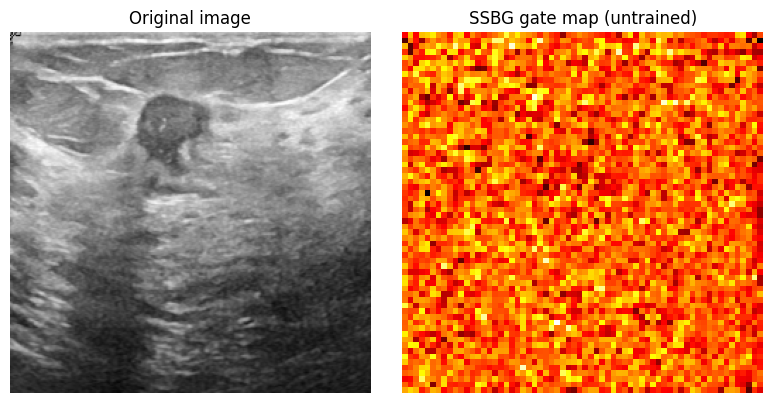

In [23]:
import matplotlib.pyplot as plt
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = real_image[0].cpu().permute(1, 2, 0).numpy()
img = (img * std + mean).clip(0, 1)

gate_map = g_real[0, 0].cpu().numpy()  # [64, 64]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img); axes[0].set_title("Original image"); axes[0].axis('off')
axes[1].imshow(gate_map, cmap='hot'); axes[1].set_title("SSBG gate map (untrained)"); axes[1].axis('off')
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# WEEK 4 — D-SAS Tier 2: AAS + SFH + Full Model Assembly
# ============================================================
# Purpose: complete the reproduced D-SAS architecture by adding
# the multi-scale semantic branch (AAS) and the boundary-semantic
# fusion module (SFH), then assemble backbone + SSBG + AAS + SFH
# + decoder into one end-to-end model for training in Week 5.
# ============================================================

In [25]:
import torch.nn.functional as F

class AAS(nn.Module):
    def __init__(self, in_ch=256, out_ch=256, dilations=(1, 2, 4, 6)):
        super().__init__()
        self.branches = nn.ModuleList()
        for d in dilations:
            # d=1 gives a standard 3x3 conv; d>1 gives dilated (atrous) convs
            conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=d, dilation=d)
            self.branches.append(nn.Sequential(conv, nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)))

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.global_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )

        self.gate = nn.Sequential(
            nn.Conv2d(out_ch * 5, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, 5, 1)  # 5 branches -> 5 weight maps
        )
        self.final = nn.Sequential(nn.Conv2d(out_ch, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        H, W = x.shape[2], x.shape[3]
        feats = [branch(x) for branch in self.branches]

        global_feat = self.global_conv(self.global_pool(x))
        global_feat = F.interpolate(global_feat, size=(H, W), mode='bilinear', align_corners=False)
        feats.append(global_feat)  # now 5 feature maps total

        concat = torch.cat(feats, dim=1)          # [B, out_ch*5, H, W]
        weights_raw = self.gate(concat)            # [B, 5, H, W]
        weights = torch.softmax(weights_raw, dim=1) # per-pixel weights across the 5 branches

        stacked = torch.stack(feats, dim=1)         # [B, 5, out_ch, H, W]
        weighted_sum = (stacked * weights.unsqueeze(2)).sum(dim=1)  # [B, out_ch, H, W]

        out = self.dropout(self.final(weighted_sum))
        return out

aas = AAS(in_ch=256, out_ch=256).to(device)
f_aas = aas(f_high_reduced)
print("F_aas:", f_aas.shape)  # expect [2, 256, 16, 16]

F_aas: torch.Size([2, 256, 16, 16])


In [26]:
with torch.no_grad():
    H, W = f_high_reduced.shape[2], f_high_reduced.shape[3]
    feats_test = [branch(f_high_reduced) for branch in aas.branches]
    global_feat_test = F.interpolate(aas.global_conv(aas.global_pool(f_high_reduced)), size=(H, W), mode='bilinear', align_corners=False)
    feats_test.append(global_feat_test)
    concat_test = torch.cat(feats_test, dim=1)
    weights_test = torch.softmax(aas.gate(concat_test), dim=1)

    print("Weights shape:", weights_test.shape)          # expect [2, 5, 16, 16]
    print("Sum across branches (should be ~1.0):", weights_test.sum(dim=1)[0,0,0].item())

Weights shape: torch.Size([2, 5, 16, 16])
Sum across branches (should be ~1.0): 0.9999999403953552


In [27]:
aas.eval()
with torch.no_grad():
    f_low_real, f_high_real = backbone(real_image)
    f_high_real_reduced = reduce_high(f_high_real)
    f_aas_real = aas(f_high_real_reduced)
print("F_aas on real image:", f_aas_real.shape)

F_aas on real image: torch.Size([1, 256, 16, 16])


In [28]:
class SFH(nn.Module):
    def __init__(self, ch=256, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gate_l = nn.Sequential(nn.Conv2d(ch * 2, ch, 1), nn.BatchNorm2d(ch), nn.Sigmoid())
        self.gate_h = nn.Sequential(nn.Conv2d(ch * 2, ch, 1), nn.BatchNorm2d(ch), nn.Sigmoid())
        self.conv_l = nn.Conv2d(ch, 1, 1)
        self.conv_h = nn.Conv2d(ch, 1, 1)
        self.out_proj = nn.Sequential(nn.Conv2d(ch, ch, 1), nn.BatchNorm2d(ch), nn.ReLU(inplace=True))

    def forward(self, f_low, f_high):
        f_high_up = F.interpolate(f_high, size=f_low.shape[2:], mode='bilinear', align_corners=False)

        cat_l = torch.cat([f_low, f_high_up], dim=1)
        cat_h = torch.cat([f_high_up, f_low], dim=1)

        g_l = self.gate_l(cat_l)
        g_h = self.gate_h(cat_h)

        f_l_hat = f_low * g_l
        f_h_hat = f_high_up * g_h

        ul = F.softplus(self.conv_l(f_l_hat)) + self.eps
        uh = F.softplus(self.conv_h(f_h_hat)) + self.eps

        fused = (f_l_hat / ul + f_h_hat / uh) / (1 / ul + 1 / uh)
        return self.out_proj(fused)

sfh = SFH(ch=256).to(device)
f_sfh = sfh(f_ssbg, f_aas)
print("F_sfh:", f_sfh.shape)  # expect [2, 256, 64, 64]

F_sfh: torch.Size([2, 256, 64, 64])


In [29]:
with torch.no_grad():
    f_high_up = F.interpolate(f_aas, size=f_ssbg.shape[2:], mode='bilinear', align_corners=False)
    cat_l = torch.cat([f_ssbg, f_high_up], dim=1)
    g_l = sfh.gate_l(cat_l)
    f_l_hat = f_ssbg * g_l
    ul = F.softplus(sfh.conv_l(f_l_hat)) + sfh.eps
    print("ul min/max (should be > 0):", ul.min().item(), ul.max().item())

ul min/max (should be > 0): 0.5585724115371704 1.048640489578247


In [30]:
with torch.no_grad():
    f_ssbg_real = ssbg(f_low_real_reduced) if 'f_low_real_reduced' in dir() else ssbg(reduce_low(f_low_real))
    f_sfh_real = sfh(f_ssbg_real, f_aas_real)
print("F_sfh on real image:", f_sfh_real.shape)

F_sfh on real image: torch.Size([1, 256, 64, 64])


In [31]:
class DSASDecoder(nn.Module):
    def __init__(self, ch=256):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(inplace=True))
        self.conv2 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(inplace=True))
        self.final = nn.Conv2d(ch, 1, kernel_size=1)

    def forward(self, x, out_size):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.final(x)
        return F.interpolate(x, size=out_size, mode='bilinear', align_corners=False)


class DSAS(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = D_SAS_Backbone()
        self.reduce_low = ChannelReduce(256, 256)
        self.reduce_high = ChannelReduce(2048, 256)
        self.ssbg = SSBG(ch=256)
        self.aas = AAS(in_ch=256, out_ch=256)
        self.sfh = SFH(ch=256)
        self.decoder = DSASDecoder(ch=256)

    def forward(self, x):
        out_size = x.shape[2:]
        f_low, f_high = self.backbone(x)
        f_low_r = self.reduce_low(f_low)
        f_high_r = self.reduce_high(f_high)
        f_ssbg_out = self.ssbg(f_low_r)
        f_aas_out = self.aas(f_high_r)
        f_sfh_out = self.sfh(f_ssbg_out, f_aas_out)
        return self.decoder(f_sfh_out, out_size)

dsas_model = DSAS().to(device)
test_input = torch.randn(2, 3, 256, 256).to(device)
output = dsas_model(test_input)
print("D-SAS output shape:", output.shape)  # expect [2, 1, 256, 256]
print("Total params:", sum(p.numel() for p in dsas_model.parameters()))

D-SAS output shape: torch.Size([2, 1, 256, 256])
Total params: 47500873


In [32]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("set_seed() defined")

set_seed() defined


In [ ]:
# ============================================================
# WEEK 5 — D-SAS Tier 2: Training and Evaluation
# ============================================================
set_seed(42)
dsas_model = DSAS().to(device)
optimizer = torch.optim.Adam(dsas_model.parameters(), lr=1e-4)
loss_fn = DiceBCELoss()

DSAS_PROJECT_DIR = f'{FINAL_DIR}/tier2_dsas'
os.makedirs(f'{DSAS_PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DSAS_PROJECT_DIR}/logs', exist_ok=True)

NUM_EPOCHS, PATIENCE = 50, 10
best_val_dice, epochs_no_improve = 0.0, 0
checkpoint_path = f'{DSAS_PROJECT_DIR}/checkpoints/dsas_best.pth'
history = []

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(dsas_model, train_loader, optimizer, loss_fn, device)
    val_loss, val_metrics = validate(dsas_model, val_loader, loss_fn, device)
    history.append({'epoch': epoch+1, 'train_loss': train_loss, 'val_loss': val_loss, **val_metrics})
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
          f"| val_dice: {val_metrics['dice']:.4f} | val_iou: {val_metrics['iou']:.4f} | {time.time()-start:.1f}s")
    if val_metrics['dice'] > best_val_dice:
        best_val_dice, epochs_no_improve = val_metrics['dice'], 0
        torch.save(dsas_model.state_dict(), checkpoint_path)
        print("  -> new best, saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

pd.DataFrame(history).to_csv(f'{DSAS_PROJECT_DIR}/logs/training_history.csv', index=False)
print(f"\nD-SAS training complete. Best val Dice: {best_val_dice:.4f}")

In [34]:
dsas_model.load_state_dict(torch.load(checkpoint_path))
dsas_model.eval()

test_loss, test_metrics = validate(dsas_model, test_loader, loss_fn, device)
print("Test set results (Tier 2 — D-SAS reproduced baseline):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

results_summary = {
    'model': 'D-SAS (Tier 2, reproduced)',
    'dataset': f'BUSI ({len(kept_records)} images, deduplicated, 70/15/15 split)',
    'params': sum(p.numel() for p in dsas_model.parameters()),
    **test_metrics
}
with open(f'{DSAS_PROJECT_DIR}/logs/test_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Saved:", f'{DSAS_PROJECT_DIR}/logs/test_results.json')

Test set results (Tier 2 — D-SAS reproduced baseline):
  dice: 0.6799
  iou: 0.5383
  precision: 0.6703
  recall: 0.7306
  specificity: 0.9723
  hd95_mean: 36.5386
  hd95_median: 20.0524
  hd95_valid_count: 80.0000
Saved: /content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results.json


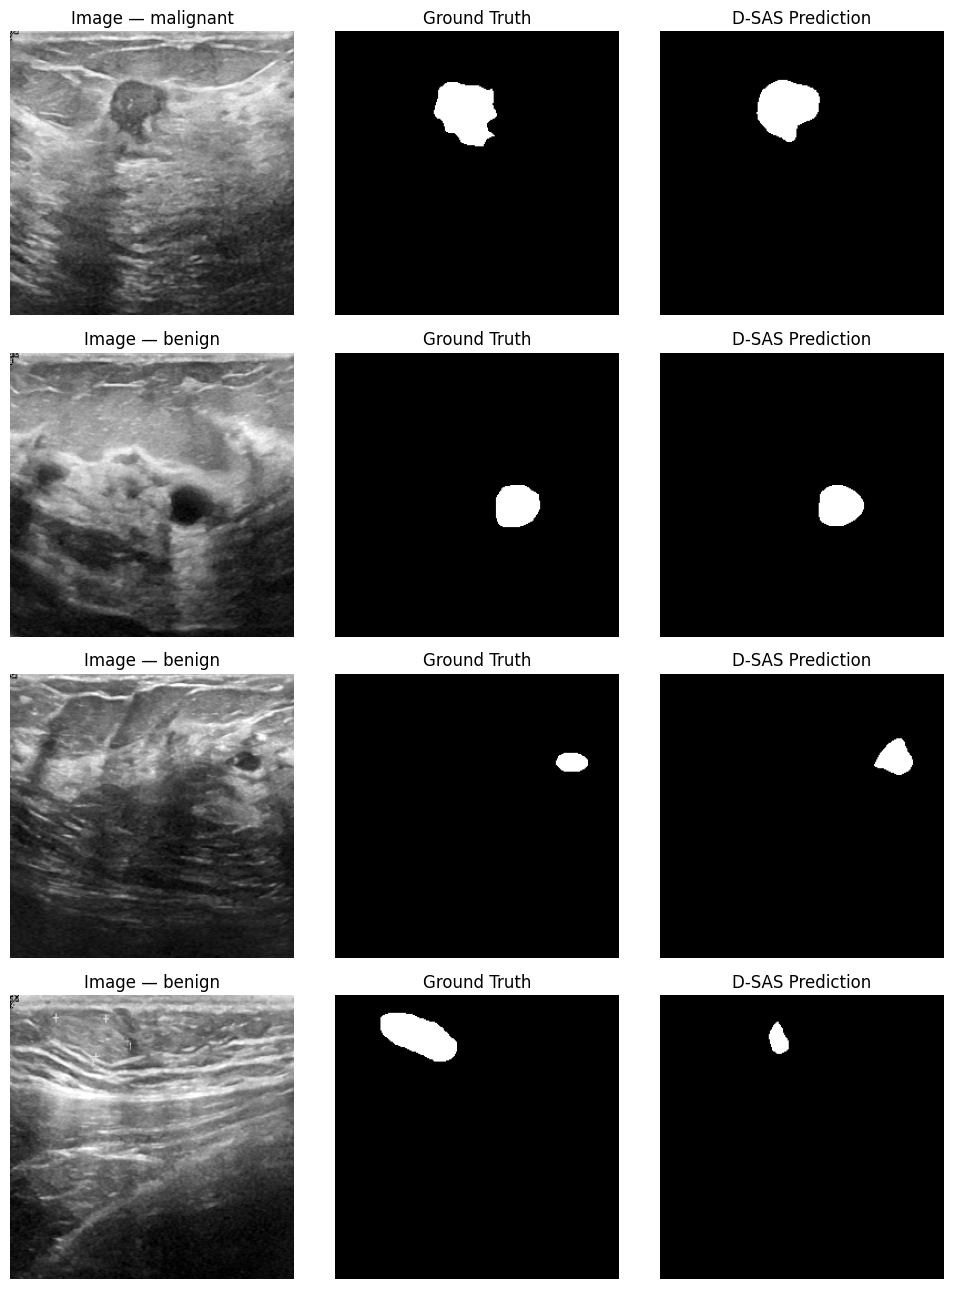

In [35]:
dsas_model.eval()
batch = next(iter(test_loader))
images, masks = batch["image"].to(device), batch["mask"].to(device)
with torch.no_grad():
    preds = torch.sigmoid(dsas_model(images)) > 0.5

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
for i in range(4):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()
    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Image — {batch['class'][i]}"); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt, cmap='gray'); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title("D-SAS Prediction"); axes[i, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{DSAS_PROJECT_DIR}/logs/sample_predictions.png', dpi=120)
plt.show()

In [45]:
# ============================================================
# WEEK 6 — CA-BSNet CORRECTED CROSS-ATTENTION
# ============================================================

class CrossAttentionBlock(nn.Module):
    """
    Semantic-guided boundary cross-attention.

    Q  = AAS semantic features
    K,V = SSBG boundary features

    AAS:
        [B, 256, 16, 16]

    SSBG:
        [B, 256, 64, 64]

    Output:
        [B, 256, 16, 16]
    """

    def __init__(self, ch=256, num_heads=4, mlp_ratio=2):
        super().__init__()

        self.norm_q = nn.LayerNorm(ch)
        self.norm_kv = nn.LayerNorm(ch)

        self.q_proj = nn.Linear(ch, ch)
        self.k_proj = nn.Linear(ch, ch)
        self.v_proj = nn.Linear(ch, ch)

        self.attn = nn.MultiheadAttention(
            embed_dim=ch,
            num_heads=num_heads,
            batch_first=True
        )

        self.out_proj = nn.Linear(ch, ch)

        self.norm2 = nn.LayerNorm(ch)

        self.mlp = nn.Sequential(
            nn.Linear(ch, ch * mlp_ratio),
            nn.GELU(),
            nn.Linear(ch * mlp_ratio, ch)
        )

    def forward(self, f_aas, f_ssbg):

        # SSBG: [B,256,64,64]
        # Resize to AAS resolution: [B,256,16,16]
        f_ssbg_small = F.interpolate(
            f_ssbg,
            size=f_aas.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        # Convert feature maps to tokens
        q_tokens = f_aas.flatten(2).transpose(1, 2)
        kv_tokens = f_ssbg_small.flatten(2).transpose(1, 2)

        # Q from AAS
        q_norm = self.norm_q(q_tokens)
        q = self.q_proj(q_norm)

        # K,V from SSBG
        kv_norm = self.norm_kv(kv_tokens)
        k = self.k_proj(kv_norm)
        v = self.v_proj(kv_norm)

        # TRUE CROSS-ATTENTION
        attn_out, attn_weights = self.attn(
            query=q,
            key=k,
            value=v,
            need_weights=True
        )

        # Residual
        tokens = q_tokens + self.out_proj(attn_out)

        # Feed-forward
        tokens = tokens + self.mlp(self.norm2(tokens))

        # Back to feature map
        B, N, C = tokens.shape
        H, W = f_aas.shape[2:]

        out = tokens.transpose(1, 2).reshape(B, C, H, W)

        return out, attn_weights


# ============================================================
# CORRECTED CA-BSNet
# ============================================================

class CABSNet(nn.Module):

    def __init__(self):
        super().__init__()

        # D-SAS backbone
        self.backbone = D_SAS_Backbone()

        self.reduce_low = ChannelReduce(256, 256)
        self.reduce_high = ChannelReduce(2048, 256)

        # D-SAS modules
        self.ssbg = SSBG(ch=256)
        self.aas = AAS(in_ch=256, out_ch=256)

        # NEW MODULE
        self.cross_attn = CrossAttentionBlock(
            ch=256,
            num_heads=4,
            mlp_ratio=2
        )

        # D-SAS modules
        self.sfh = SFH(ch=256)
        self.decoder = DSASDecoder(ch=256)

    def forward(self, x):

        out_size = x.shape[2:]

        # Backbone
        f_low, f_high = self.backbone(x)

        # Channel reduction
        f_low_r = self.reduce_low(f_low)
        f_high_r = self.reduce_high(f_high)

        # SSBG
        f_ssbg_out = self.ssbg(f_low_r)

        # AAS
        f_aas_out = self.aas(f_high_r)

        # ====================================================
        # NEW CROSS-ATTENTION
        # Q  = AAS
        # K,V = SSBG
        # ====================================================
        f_ca_out, _ = self.cross_attn(
            f_aas_out,
            f_ssbg_out
        )

        # SFH
        f_sfh_out = self.sfh(
            f_ssbg_out,
            f_ca_out
        )

        # Decoder
        output = self.decoder(
            f_sfh_out,
            out_size
        )

        return output


# ============================================================
# SANITY CHECK
# ============================================================

set_seed(42)

ca_bsnet_model = CABSNet().to(device)
ca_bsnet_model.eval()

test_input = torch.randn(
    2, 3, 256, 256
).to(device)

with torch.no_grad():
    test_output = ca_bsnet_model(test_input)

print("CA-BSNet output shape:", test_output.shape)
print("Expected: [2, 1, 256, 256]")

print(
    "Total parameters:",
    sum(p.numel() for p in ca_bsnet_model.parameters())
)

print(
    "Cross-attention parameters:",
    sum(p.numel() for p in ca_bsnet_model.cross_attn.parameters())
)

CA-BSNet output shape: torch.Size([2, 1, 256, 256])
Expected: [2, 1, 256, 256]
Total parameters: 48291657
Cross-attention parameters: 790784


In [46]:
# ============================================================
# CROSS-ATTENTION SANITY CHECK
# ============================================================

ca_bsnet_model.eval()

with torch.no_grad():

    f_low, f_high = ca_bsnet_model.backbone(test_input)

    f_low_r = ca_bsnet_model.reduce_low(f_low)
    f_high_r = ca_bsnet_model.reduce_high(f_high)

    f_ssbg = ca_bsnet_model.ssbg(f_low_r)
    f_aas = ca_bsnet_model.aas(f_high_r)

    f_ca, attn_weights = ca_bsnet_model.cross_attn(
        f_aas,
        f_ssbg
    )

print("SSBG:", f_ssbg.shape)
print("AAS :", f_aas.shape)
print("CA  :", f_ca.shape)
print("Attention:", attn_weights.shape)

print(
    "Attention row-sum:",
    attn_weights.sum(dim=-1).min().item(),
    attn_weights.sum(dim=-1).max().item()
)

SSBG: torch.Size([2, 256, 64, 64])
AAS : torch.Size([2, 256, 16, 16])
CA  : torch.Size([2, 256, 16, 16])
Attention: torch.Size([2, 256, 256])
Attention row-sum: 0.9999998807907104 1.0000001192092896


In [47]:
set_seed(42)
ca_bsnet_model = CABSNet().to(device)

optimizer = torch.optim.Adam(
    ca_bsnet_model.parameters(),
    lr=1e-4
)

loss_fn = DiceBCELoss()

In [48]:
# ============================================================
# CA-BSNet Training — Tier 3
# ============================================================

CA_BSNET_PROJECT_DIR = f'{FINAL_DIR}/tier3_cabsnet'

os.makedirs(f'{CA_BSNET_PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{CA_BSNET_PROJECT_DIR}/logs', exist_ok=True)

NUM_EPOCHS = 50
PATIENCE = 10

best_val_dice = 0.0
epochs_no_improve = 0

checkpoint_path = f'{CA_BSNET_PROJECT_DIR}/checkpoints/cabsnet_best.pth'

history = []

for epoch in range(NUM_EPOCHS):

    start = time.time()

    # -------------------------
    # Training
    # -------------------------
    train_loss = train_one_epoch(
        ca_bsnet_model,
        train_loader,
        optimizer,
        loss_fn,
        device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_metrics = validate(
        ca_bsnet_model,
        val_loader,
        loss_fn,
        device
    )

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        **val_metrics
    })

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss: {train_loss:.4f} | "
        f"val_loss: {val_loss:.4f} | "
        f"val_dice: {val_metrics['dice']:.4f} | "
        f"val_iou: {val_metrics['iou']:.4f} | "
        f"{time.time()-start:.1f}s"
    )

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if val_metrics['dice'] > best_val_dice:

        best_val_dice = val_metrics['dice']
        epochs_no_improve = 0

        torch.save(
            ca_bsnet_model.state_dict(),
            checkpoint_path
        )

        print("  -> new best, saved")

    else:

        epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:

            print(
                f"Early stopping at epoch {epoch+1}"
            )

            break


# ============================================================
# Save training history
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    f'{CA_BSNET_PROJECT_DIR}/logs/training_history.csv',
    index=False
)

print(
    f"\nCA-BSNet training complete. "
    f"Best val Dice: {best_val_dice:.4f}"
)

print(
    "Checkpoint:",
    checkpoint_path
)

Epoch 1/50 | train_loss: 1.2795 | val_loss: 1.3528 | val_dice: 0.0638 | val_iou: 0.0338 | 16.2s
  -> new best, saved
Epoch 2/50 | train_loss: 0.9090 | val_loss: 0.8891 | val_dice: 0.5579 | val_iou: 0.3886 | 17.4s
  -> new best, saved
Epoch 3/50 | train_loss: 0.7504 | val_loss: 0.7479 | val_dice: 0.6774 | val_iou: 0.5161 | 17.6s
  -> new best, saved
Epoch 4/50 | train_loss: 0.6721 | val_loss: 0.7085 | val_dice: 0.6821 | val_iou: 0.5198 | 20.3s
  -> new best, saved
Epoch 5/50 | train_loss: 0.5662 | val_loss: 0.6470 | val_dice: 0.7090 | val_iou: 0.5530 | 19.7s
  -> new best, saved
Epoch 6/50 | train_loss: 0.5147 | val_loss: 0.6666 | val_dice: 0.6804 | val_iou: 0.5205 | 17.5s
Epoch 7/50 | train_loss: 0.4785 | val_loss: 0.5817 | val_dice: 0.7127 | val_iou: 0.5575 | 17.0s
  -> new best, saved
Epoch 8/50 | train_loss: 0.4125 | val_loss: 0.5828 | val_dice: 0.7276 | val_iou: 0.5749 | 17.8s
  -> new best, saved
Epoch 9/50 | train_loss: 0.3960 | val_loss: 0.5524 | val_dice: 0.7287 | val_iou: 0.57

In [49]:
# ============================================================
# Load Best CA-BSNet Checkpoint
# ============================================================

ca_bsnet_model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

ca_bsnet_model.eval()

print("Best CA-BSNet checkpoint loaded.")

Best CA-BSNet checkpoint loaded.


In [50]:
# ============================================================
# CA-BSNet Test Evaluation
# ============================================================

test_loss, test_metrics = validate(
    ca_bsnet_model,
    test_loader,
    loss_fn,
    device
)

print("\n" + "="*60)
print("CA-BSNet Test Set Results (Tier 3)")
print("="*60)

print(f"Dice       : {test_metrics['dice']:.4f}")
print(f"IoU        : {test_metrics['iou']:.4f}")
print(f"Precision  : {test_metrics['precision']:.4f}")
print(f"Recall     : {test_metrics['recall']:.4f}")
print(f"Specificity: {test_metrics['specificity']:.4f}")

if 'hd95_mean' in test_metrics:
    print(f"HD95 Mean  : {test_metrics['hd95_mean']:.4f}")

if 'hd95_median' in test_metrics:
    print(f"HD95 Median: {test_metrics['hd95_median']:.4f}")


CA-BSNet Test Set Results (Tier 3)
Dice       : 0.7090
IoU        : 0.5617
Precision  : 0.6517
Recall     : 0.8273
Specificity: 0.9652
HD95 Mean  : 36.3330
HD95 Median: 19.9896


In [51]:
# ============================================================
# Save CA-BSNet Test Results
# ============================================================

results_summary = {
    'model': 'CA-BSNet (Tier 3)',
    'dataset': f'BUSI ({len(kept_records)} images, deduplicated, 70/15/15 split)',
    'params': sum(p.numel() for p in ca_bsnet_model.parameters()),
    **test_metrics
}

with open(
    f'{CA_BSNET_PROJECT_DIR}/logs/test_results.json',
    'w'
) as f:
    json.dump(results_summary, f, indent=2)

print(
    "\nSaved:",
    f'{CA_BSNET_PROJECT_DIR}/logs/test_results.json'
)


Saved: /content/drive/MyDrive/BUSI_Dataset/tier3_cabsnet/logs/test_results.json


In [52]:
# ============================================================
# COMPLETE MODEL COMPARISON — ALL 4 MODELS
# ============================================================

import json
import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

RESULT_FILES = {
    "Attention U-Net":
        f"{FINAL_DIR}/tier1_attention_unet/logs/test_results.json",

    "D-SAS":
        f"{FINAL_DIR}/tier2_dsas/logs/test_results.json",

    "CA-BSNet (Original)":
        f"{FINAL_DIR}/tier3_cabsnet_original/logs/test_results.json",

    "CA-BSNet (Corrected)":
        f"{FINAL_DIR}/tier3_cabsnet/logs/test_results.json",
}

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------

all_results = []

for model_name, path in RESULT_FILES.items():

    if not os.path.exists(path):
        print(f"WARNING: File not found -> {path}")
        continue

    with open(path, "r") as f:
        result = json.load(f)

    result["Model"] = model_name

    all_results.append(result)


# ------------------------------------------------------------
# Create comparison DataFrame
# ------------------------------------------------------------

comparison_df = pd.DataFrame(all_results)

# Keep only the important metrics
columns = [
    "Model",
    "params",
    "dice",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95_mean",
    "hd95_median"
]

# Keep only columns that actually exist
columns = [c for c in columns if c in comparison_df.columns]

comparison_df = comparison_df[columns]

# Rename for presentation
comparison_df = comparison_df.rename(columns={
    "params": "Parameters",
    "dice": "Dice",
    "iou": "IoU",
    "precision": "Precision",
    "recall": "Recall",
    "specificity": "Specificity",
    "hd95_mean": "HD95 Mean",
    "hd95_median": "HD95 Median"
})

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("COMPLETE MODEL COMPARISON")
print("=" * 100)

display(
    comparison_df.style
    .format({
        "Parameters": "{:,.0f}",
        "Dice": "{:.4f}",
        "IoU": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Specificity": "{:.4f}",
        "HD95 Mean": "{:.4f}",
        "HD95 Median": "{:.4f}"
    })
)


COMPLETE MODEL COMPARISON


,Model,Parameters,Dice,IoU,Precision,Recall,Specificity,HD95 Mean,HD95 Median
0,Attention U-Net,nan,0.5786,0.4457,0.5662,0.6175,0.9515,55.8403,38.8330
1,D-SAS,"47,500,873",0.6799,0.5383,0.6703,0.7306,0.9723,36.5386,20.0524
2,CA-BSNet (Corrected),"48,291,657",0.7090,0.5617,0.6517,0.8273,0.9652,36.3330,19.9896


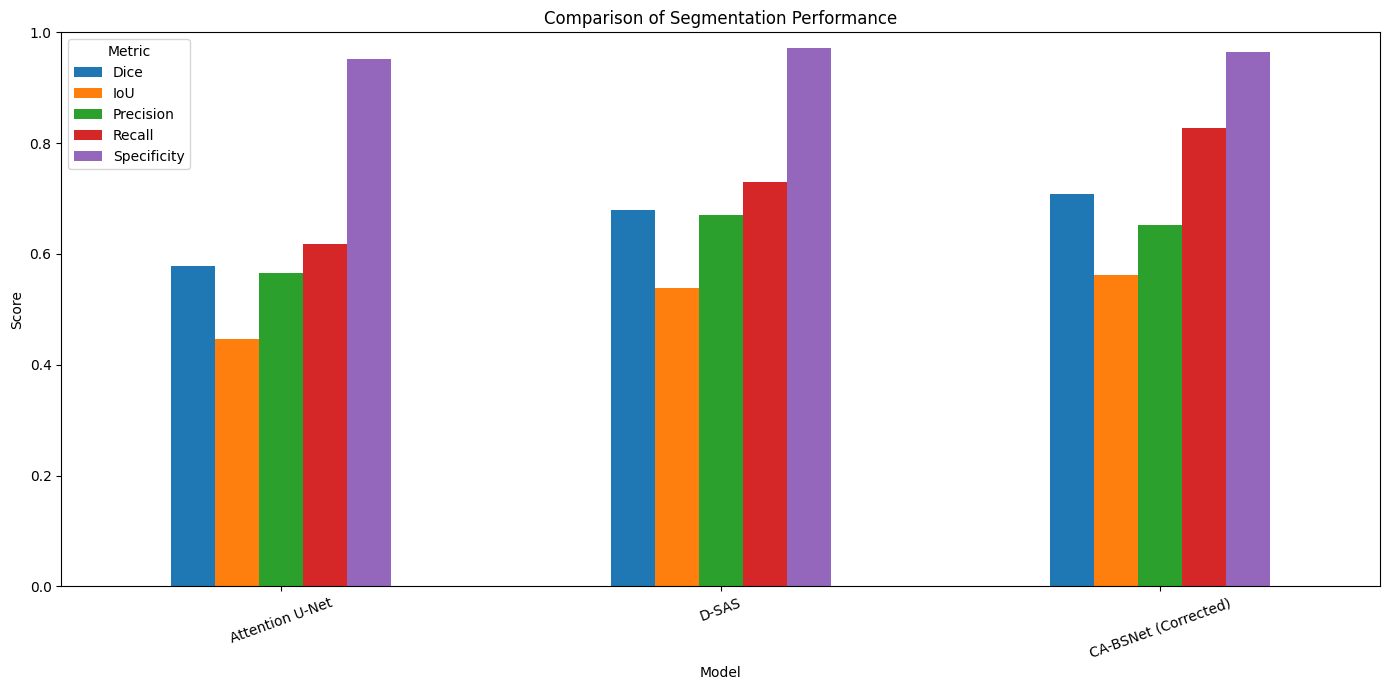

In [53]:
# ============================================================
# OVERALL SEGMENTATION PERFORMANCE
# ============================================================

metrics_to_plot = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity"
]

plot_df = comparison_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparison of Segmentation Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# BEST MODEL FOR EACH METRIC
# ============================================================

print("\n" + "=" * 80)
print("BEST MODEL BY METRIC")
print("=" * 80)

higher_is_better = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity"
]

lower_is_better = [
    "HD95 Mean",
    "HD95 Median"
]

for metric in higher_is_better:

    if metric in comparison_df.columns:

        idx = comparison_df[metric].idxmax()

        print(
            f"{metric:<15} : "
            f"{comparison_df.loc[idx, 'Model']} "
            f"({comparison_df.loc[idx, metric]:.4f})"
        )

for metric in lower_is_better:

    if metric in comparison_df.columns:

        idx = comparison_df[metric].idxmin()

        print(
            f"{metric:<15} : "
            f"{comparison_df.loc[idx, 'Model']} "
            f"({comparison_df.loc[idx, metric]:.4f})"
        )


BEST MODEL BY METRIC
Dice            : CA-BSNet (Corrected) (0.7090)
IoU             : CA-BSNet (Corrected) (0.5617)
Precision       : D-SAS (0.6703)
Recall          : CA-BSNet (Corrected) (0.8273)
Specificity     : D-SAS (0.9723)
HD95 Mean       : CA-BSNet (Corrected) (36.3330)
HD95 Median     : CA-BSNet (Corrected) (19.9896)


In [55]:
# ============================================================
# FIND ALL SAVED TEST RESULT FILES
# ============================================================

import os

search_root = FINAL_DIR

print("Searching for test_results.json files...\n")

found_files = []

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file == "test_results.json":
            path = os.path.join(root, file)
            found_files.append(path)

if found_files:
    for path in found_files:
        print(path)
else:
    print("No test_results.json files found.")

Searching for test_results.json files...

/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/logs/test_results.json
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results.json
/content/drive/MyDrive/BUSI_Dataset/tier3_cabsnet/logs/test_results.json


In [56]:
# ============================================================
# SHOW ALL MODEL / RESULT FOLDERS
# ============================================================

for item in os.listdir(FINAL_DIR):
    path = os.path.join(FINAL_DIR, item)

    if os.path.isdir(path):
        print(item)

Dataset_BUSI_with_GT
tier1_attention_unet
tier2_dsas
tier3_cabsnet


In [57]:
# ============================================================
# 3-SEED ROBUSTNESS EXPERIMENT
# D-SAS vs CORRECTED CA-BSNet
# Seeds 42, 43, 44
# ============================================================

import os
import json
import time
import copy
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

SEEDS = [43, 44]   # Seed 42 already completed
NUM_EPOCHS = 50
PATIENCE = 10
LR = 1e-4

DSAS_DIR = f"{FINAL_DIR}/tier2_dsas"
CABSNET_DIR = f"{FINAL_DIR}/tier3_cabsnet"

os.makedirs(f"{DSAS_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{DSAS_DIR}/logs", exist_ok=True)

os.makedirs(f"{CABSNET_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{CABSNET_DIR}/logs", exist_ok=True)

# ------------------------------------------------------------
# EXISTING SEED-42 RESULTS
# These are the results you already obtained.
# ------------------------------------------------------------

seed42_results = {
    "dsas": {
        "seed": 42,
        "dice": 0.6140,
        "iou": 0.4897,
        "precision": 0.6936,
        "recall": 0.5567,
        "specificity": 0.9693,
        "hd95_mean": 35.2437,
        "hd95_median": 17.0352
    },

    "ca_bsnet": {
        "seed": 42,
        "dice": 0.6276,
        "iou": 0.5018,
        "precision": 0.7011,
        "recall": 0.5729,
        "specificity": 0.9796,
        "hd95_mean": 34.7361,
        "hd95_median": 19.4648
    }
}

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

multi_seed_results = {
    "dsas": [seed42_results["dsas"]],
    "ca_bsnet": [seed42_results["ca_bsnet"]]
}

# ------------------------------------------------------------
# TRAINING FUNCTION
# ------------------------------------------------------------

def train_model_for_seed(
    model_name,
    model_class,
    seed,
    checkpoint_path
):

    print("\n" + "=" * 80)
    print(f"SEED {seed} — {model_name}")
    print("=" * 80)

    # --------------------------------------------------------
    # Set seed BEFORE model creation
    # --------------------------------------------------------
    set_seed(seed)

    # --------------------------------------------------------
    # Create fresh model
    # --------------------------------------------------------
    model = model_class().to(device)

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR
    )

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------
    loss_fn = DiceBCELoss()

    best_val_dice = -1.0
    best_epoch = 0
    epochs_no_improve = 0

    training_history = []

    start_total = time.time()

    # --------------------------------------------------------
    # Training loop
    # --------------------------------------------------------
    for epoch in range(NUM_EPOCHS):

        epoch_start = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device
        )

        val_loss, val_metrics = validate(
            model,
            val_loader,
            loss_fn,
            device
        )

        epoch_time = time.time() - epoch_start

        current_val_dice = val_metrics["dice"]

        training_history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **val_metrics
        })

        print(
            f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Dice: {current_val_dice:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        # ----------------------------------------------------
        # Save best model according to validation Dice
        # ----------------------------------------------------
        if current_val_dice > best_val_dice:

            best_val_dice = current_val_dice
            best_epoch = epoch + 1
            epochs_no_improve = 0

            torch.save(
                model.state_dict(),
                checkpoint_path
            )

            print(
                f"  -> New best model saved "
                f"(Val Dice: {best_val_dice:.4f})"
            )

        else:

            epochs_no_improve += 1

            if epochs_no_improve >= PATIENCE:

                print(
                    f"  -> Early stopping at epoch "
                    f"{epoch + 1}"
                )

                break

    total_time = time.time() - start_total

    # --------------------------------------------------------
    # Save training history
    # --------------------------------------------------------

    history_df = pd.DataFrame(training_history)

    model_key = (
        "dsas"
        if model_name == "D-SAS"
        else "ca_bsnet"
    )

    history_path = os.path.join(
        os.path.dirname(os.path.dirname(checkpoint_path)),
        "logs",
        f"training_history_seed{seed}.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print("\nTraining complete.")
    print(f"Best epoch      : {best_epoch}")
    print(f"Best Val Dice   : {best_val_dice:.4f}")
    print(f"Total time      : {total_time / 60:.2f} minutes")

    # --------------------------------------------------------
    # Load BEST checkpoint
    # --------------------------------------------------------

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------

    print("\nEvaluating best checkpoint on TEST set...")

    test_loss, test_metrics = validate(
        model,
        test_loader,
        loss_fn,
        device
    )

    result = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": float(best_val_dice),
        "test_loss": float(test_loss),

        "dice": float(test_metrics["dice"]),
        "iou": float(test_metrics["iou"]),
        "precision": float(test_metrics["precision"]),
        "recall": float(test_metrics["recall"]),
        "specificity": float(test_metrics["specificity"]),
        "hd95_mean": float(test_metrics["hd95_mean"]),
        "hd95_median": float(test_metrics["hd95_median"])
    }

    print("\nTEST RESULTS")
    print("-" * 50)

    for key, value in result.items():

        if isinstance(value, float):
            print(f"{key:20s}: {value:.4f}")
        else:
            print(f"{key:20s}: {value}")

    # --------------------------------------------------------
    # Save individual seed result
    # --------------------------------------------------------

    result_path = os.path.join(
        os.path.dirname(os.path.dirname(checkpoint_path)),
        "logs",
        f"test_results_seed{seed}.json"
    )

    with open(result_path, "w") as f:
        json.dump(
            result,
            f,
            indent=2
        )

    print(f"\nSaved result: {result_path}")

    # --------------------------------------------------------
    # Free GPU memory
    # --------------------------------------------------------

    del model
    del optimizer

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# ============================================================
# RUN SEEDS 43 AND 44
# ============================================================

for seed in SEEDS:

    # ========================================================
    # D-SAS
    # ========================================================

    dsas_checkpoint = (
        f"{DSAS_DIR}/checkpoints/"
        f"dsas_seed{seed}.pth"
    )

    dsas_result = train_model_for_seed(
        model_name="D-SAS",
        model_class=DSAS,
        seed=seed,
        checkpoint_path=dsas_checkpoint
    )

    multi_seed_results["dsas"].append(
        dsas_result
    )

    # ========================================================
    # CORRECTED CA-BSNet
    # ========================================================

    ca_checkpoint = (
        f"{CABSNET_DIR}/checkpoints/"
        f"cabsnet_seed{seed}.pth"
    )

    ca_result = train_model_for_seed(
        model_name="CA-BSNet (Corrected)",
        model_class=CABSNet,
        seed=seed,
        checkpoint_path=ca_checkpoint
    )

    multi_seed_results["ca_bsnet"].append(
        ca_result
    )


# ============================================================
# SAVE COMPLETE RAW RESULTS
# ============================================================

raw_results_path = (
    f"{FINAL_DIR}/multi_seed_results_42_43_44.json"
)

with open(raw_results_path, "w") as f:

    json.dump(
        multi_seed_results,
        f,
        indent=2
    )

print("\n" + "=" * 80)
print("RAW MULTI-SEED RESULTS SAVED")
print("=" * 80)
print(raw_results_path)


# ============================================================
# CALCULATE MEAN ± STD
# ============================================================

METRICS = [
    "dice",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95_mean",
    "hd95_median"
]

metric_names = {
    "dice": "Dice",
    "iou": "IoU",
    "precision": "Precision",
    "recall": "Recall",
    "specificity": "Specificity",
    "hd95_mean": "HD95 Mean",
    "hd95_median": "HD95 Median"
}

summary_rows = []

for model_key, model_results in multi_seed_results.items():

    row = {
        "Model": (
            "D-SAS"
            if model_key == "dsas"
            else "CA-BSNet (Corrected)"
        )
    }

    for metric in METRICS:

        values = [
            float(result[metric])
            for result in model_results
        ]

        mean_value = np.mean(values)

        # Sample standard deviation
        std_value = np.std(
            values,
            ddof=1
        )

        row[metric_names[metric]] = (
            f"{mean_value:.4f} ± {std_value:.4f}"
        )

    summary_rows.append(row)


summary_df = pd.DataFrame(
    summary_rows
)


# ============================================================
# PRINT FINAL TABLE
# ============================================================

print("\n")
print("=" * 110)
print("FINAL 3-SEED COMPARISON")
print("Seeds: 42, 43, 44")
print("=" * 110)

print(
    summary_df.to_string(
        index=False
    )
)


# ============================================================
# NUMERICAL MEANS FOR DIRECT COMPARISON
# ============================================================

print("\n")
print("=" * 80)
print("NUMERICAL MEANS")
print("=" * 80)

for model_key, model_results in multi_seed_results.items():

    model_name = (
        "D-SAS"
        if model_key == "dsas"
        else "CA-BSNet (Corrected)"
    )

    print(f"\n{model_name}")

    for metric in METRICS:

        values = [
            float(result[metric])
            for result in model_results
        ]

        mean_value = np.mean(values)
        std_value = np.std(
            values,
            ddof=1
        )

        print(
            f"{metric_names[metric]:15s}: "
            f"{mean_value:.4f} ± {std_value:.4f}"
        )


# ============================================================
# CA-BSNet IMPROVEMENT OVER D-SAS
# ============================================================

print("\n")
print("=" * 80)
print("CA-BSNet vs D-SAS — MEAN DIFFERENCE")
print("=" * 80)

dsas_data = multi_seed_results["dsas"]
ca_data = multi_seed_results["ca_bsnet"]

for metric in METRICS:

    dsas_values = np.array([
        float(r[metric])
        for r in dsas_data
    ])

    ca_values = np.array([
        float(r[metric])
        for r in ca_data
    ])

    dsas_mean = np.mean(dsas_values)
    ca_mean = np.mean(ca_values)

    difference = ca_mean - dsas_mean

    # For HD95, lower is better
    direction = "better" if (
        difference > 0
        if metric not in ["hd95_mean", "hd95_median"]
        else difference < 0
    ) else "worse"

    print(
        f"{metric_names[metric]:15s}: "
        f"{difference:+.4f} ({direction})"
    )


# ============================================================
# SAVE SUMMARY CSV
# ============================================================

summary_csv_path = (
    f"{FINAL_DIR}/multi_seed_summary_42_43_44.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)

print("\n")
print("=" * 80)
print("SUMMARY SAVED")
print("=" * 80)
print(summary_csv_path)


# ============================================================
# SAVE DETAILED NUMERICAL SUMMARY JSON
# ============================================================

numerical_summary = {}

for model_key, model_results in multi_seed_results.items():

    model_name = (
        "D-SAS"
        if model_key == "dsas"
        else "CA-BSNet (Corrected)"
    )

    numerical_summary[model_name] = {}

    for metric in METRICS:

        values = [
            float(r[metric])
            for r in model_results
        ]

        numerical_summary[model_name][metric] = {
            "values": values,
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1))
        }


numerical_json_path = (
    f"{FINAL_DIR}/multi_seed_numerical_summary.json"
)

with open(numerical_json_path, "w") as f:

    json.dump(
        numerical_summary,
        f,
        indent=2
    )

print(numerical_json_path)

print("\n")
print("=" * 80)
print("3-SEED EXPERIMENT COMPLETE")
print("=" * 80)


SEED 43 — D-SAS
Epoch 01/50 | Train Loss: 1.2532 | Val Loss: 1.3806 | Val Dice: 0.5022 | Time: 17.8s
  -> New best model saved (Val Dice: 0.5022)
Epoch 02/50 | Train Loss: 0.9340 | Val Loss: 0.9357 | Val Dice: 0.5991 | Time: 19.5s
  -> New best model saved (Val Dice: 0.5991)
Epoch 03/50 | Train Loss: 0.7653 | Val Loss: 0.7142 | Val Dice: 0.6676 | Time: 18.1s
  -> New best model saved (Val Dice: 0.6676)
Epoch 04/50 | Train Loss: 0.6509 | Val Loss: 0.6696 | Val Dice: 0.6756 | Time: 17.7s
  -> New best model saved (Val Dice: 0.6756)
Epoch 05/50 | Train Loss: 0.5615 | Val Loss: 0.6440 | Val Dice: 0.7077 | Time: 18.5s
  -> New best model saved (Val Dice: 0.7077)
Epoch 06/50 | Train Loss: 0.5048 | Val Loss: 0.6192 | Val Dice: 0.7049 | Time: 18.0s
Epoch 07/50 | Train Loss: 0.4726 | Val Loss: 0.5993 | Val Dice: 0.6930 | Time: 17.4s
Epoch 08/50 | Train Loss: 0.4152 | Val Loss: 0.6119 | Val Dice: 0.6869 | Time: 17.3s
Epoch 09/50 | Train Loss: 0.3833 | Val Loss: 0.5373 | Val Dice: 0.7255 | Time:

KeyboardInterrupt: 

In [58]:
print(len(multi_seed_results["dsas"]), len(multi_seed_results["ca_bsnet"]))

3 2


In [59]:
ca_checkpoint_44 = f"{CABSNET_DIR}/checkpoints/cabsnet_seed44.pth"
ca_result_44 = train_model_for_seed(
    model_name="CA-BSNet (Corrected)",
    model_class=CABSNet,
    seed=44,
    checkpoint_path=ca_checkpoint_44
)
multi_seed_results["ca_bsnet"].append(ca_result_44)


SEED 44 — CA-BSNet (Corrected)
Epoch 01/50 | Train Loss: 1.2376 | Val Loss: 1.3266 | Val Dice: 0.0643 | Time: 17.8s
  -> New best model saved (Val Dice: 0.0643)
Epoch 02/50 | Train Loss: 0.8875 | Val Loss: 0.8993 | Val Dice: 0.6365 | Time: 18.4s
  -> New best model saved (Val Dice: 0.6365)
Epoch 03/50 | Train Loss: 0.7364 | Val Loss: 0.7011 | Val Dice: 0.7026 | Time: 18.9s
  -> New best model saved (Val Dice: 0.7026)
Epoch 04/50 | Train Loss: 0.6159 | Val Loss: 0.6487 | Val Dice: 0.7049 | Time: 18.0s
  -> New best model saved (Val Dice: 0.7049)
Epoch 05/50 | Train Loss: 0.5370 | Val Loss: 0.6250 | Val Dice: 0.7074 | Time: 19.9s
  -> New best model saved (Val Dice: 0.7074)
Epoch 06/50 | Train Loss: 0.4931 | Val Loss: 0.6073 | Val Dice: 0.7156 | Time: 18.0s
  -> New best model saved (Val Dice: 0.7156)
Epoch 07/50 | Train Loss: 0.4538 | Val Loss: 0.5738 | Val Dice: 0.7322 | Time: 19.0s
  -> New best model saved (Val Dice: 0.7322)
Epoch 08/50 | Train Loss: 0.4079 | Val Loss: 0.5430 | Val 

In [60]:
print(len(multi_seed_results["dsas"]), len(multi_seed_results["ca_bsnet"]))
# Expect: 3 3

3 3


In [61]:
import os

BASE = "/content/drive/MyDrive"

print("=" * 100)
print("SEARCHING GOOGLE DRIVE")
print("=" * 100)

keywords = [
    "test_results",
    "per_image",
    "prediction",
    "predictions",
    "bootstrap",
    "multi_seed",
    "seed42",
    "seed43",
    "seed44",
    "cabsnet",
    "dsas"
]

matches = []

for root, dirs, files in os.walk(BASE):
    for f in files:
        if any(k in f.lower() for k in keywords):
            matches.append(os.path.join(root, f))

if matches:
    for path in sorted(matches):
        print(path)
else:
    print("NO MATCHING FILES FOUND")

print("\nTotal:", len(matches))

SEARCHING GOOGLE DRIVE
/content/drive/MyDrive/BUSI_Dataset/bootstrap_comparison_cabsnet_vs_dsas.json
/content/drive/MyDrive/BUSI_Dataset/multi_seed_numerical_summary.json
/content/drive/MyDrive/BUSI_Dataset/multi_seed_results_42_43_44.json
/content/drive/MyDrive/BUSI_Dataset/multi_seed_summary_42_43_44.csv
/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/logs/sample_predictions.png
/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/logs/test_results.json
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/checkpoints/dsas_best.pth
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/checkpoints/dsas_seed43.pth
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/checkpoints/dsas_seed44.pth
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/sample_predictions.png
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results.json
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results_seed43.json
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results_seed44.json
/cont

In [62]:
import os

paths = [
    "/content/drive/MyDrive/BUSI_Dataset/tier2_dsas",
    "/content/drive/MyDrive/BUSI_Dataset/tier3_cabsnet",
]

for p in paths:
    print("\n" + "=" * 100)
    print(p)
    print("=" * 100)

    if os.path.exists(p):
        for root, dirs, files in os.walk(p):
            level = root.replace(p, "").count(os.sep)
            indent = "  " * level
            print(indent + os.path.basename(root) + "/")

            for f in files:
                print(indent + "  " + f)
    else:
        print("NOT FOUND")


/content/drive/MyDrive/BUSI_Dataset/tier2_dsas
tier2_dsas/
  checkpoints/
    dsas_best.pth
    dsas_seed43.pth
    dsas_seed44.pth
  logs/
    training_history.csv
    test_results.json
    sample_predictions.png
    training_history_seed43.csv
    test_results_seed43.json
    training_history_seed44.csv
    test_results_seed44.json

/content/drive/MyDrive/BUSI_Dataset/tier3_cabsnet
tier3_cabsnet/
  checkpoints/
    cabsnet_best.pth
    cabsnet_seed43.pth
    cabsnet_seed44.pth
  logs/
    sample_predictions.png
    training_history.csv
    test_results.json
    training_history_seed43.csv
    test_results_seed43.json
    training_history_seed44.csv
    test_results_seed44.json


In [63]:
import os

BASE = "/content/drive/MyDrive"

print("=" * 100)
print("SEARCHING GOOGLE DRIVE FOR BUSI EXPERIMENT FILES")
print("=" * 100)

matches = []

for root, dirs, files in os.walk(BASE):
    for f in files:
        fl = f.lower()

        if (
            "seed43" in fl
            or "seed44" in fl
            or "seed42" in fl
            or "multi_seed" in fl
            or "test_results" in fl
            or "cabsnet" in fl
            or "dsas" in fl
            or "per_image" in fl
            or "prediction" in fl
            or "bootstrap" in fl
        ):
            matches.append(os.path.join(root, f))

if matches:
    for p in sorted(matches):
        print(p)
else:
    print("NO MATCHING FILES FOUND")

SEARCHING GOOGLE DRIVE FOR BUSI EXPERIMENT FILES
/content/drive/MyDrive/BUSI_Dataset/bootstrap_comparison_cabsnet_vs_dsas.json
/content/drive/MyDrive/BUSI_Dataset/multi_seed_numerical_summary.json
/content/drive/MyDrive/BUSI_Dataset/multi_seed_results_42_43_44.json
/content/drive/MyDrive/BUSI_Dataset/multi_seed_summary_42_43_44.csv
/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/logs/sample_predictions.png
/content/drive/MyDrive/BUSI_Dataset/tier1_attention_unet/logs/test_results.json
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/checkpoints/dsas_best.pth
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/checkpoints/dsas_seed43.pth
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/checkpoints/dsas_seed44.pth
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/sample_predictions.png
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results.json
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results_seed43.json
/content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test

In [64]:
import os

print("Drive exists:", os.path.exists("/content/drive"))
print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

if os.path.exists("/content/drive/MyDrive"):
    print("\nTop-level MyDrive contents:")
    for item in os.listdir("/content/drive/MyDrive"):
        print(" -", item)

Drive exists: True
MyDrive exists: True

Top-level MyDrive contents:
 - Project
 - paper analysis.docx
 - Colab Notebooks
 - Progress_Update_Traditional.pptx
 - Proposed_System_Breast_Lesion_Segmentation.md.pdf
 - Proposed_System_Breast_Lesion_Segmentation (1).pdf
 - BUSI_Dataset
 - breast_us_project


In [65]:
import os

print("Drive exists:", os.path.exists("/content/drive"))
print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

if os.path.exists("/content/drive/MyDrive"):
    print("\nTop-level MyDrive contents:")
    print(os.listdir("/content/drive/MyDrive")[:50])

Drive exists: True
MyDrive exists: True

Top-level MyDrive contents:
['Project', 'paper analysis.docx', 'Colab Notebooks', 'Progress_Update_Traditional.pptx', 'Proposed_System_Breast_Lesion_Segmentation.md.pdf', 'Proposed_System_Breast_Lesion_Segmentation (1).pdf', 'BUSI_Dataset', 'breast_us_project']


In [67]:
def collect_per_image_metrics(model, loader, device):
    model.eval()
    records = []
    with torch.no_grad():
        for batch in loader:
            images, masks = batch["image"].to(device), batch["mask"].to(device)
            preds = model(images)
            for i in range(images.shape[0]):
                m = compute_metrics(preds[i:i+1], masks[i:i+1])
                pred_bin = (torch.sigmoid(preds[i:i+1]) > 0.5).cpu().numpy().astype(bool)[0, 0]
                gt_bin = masks[i:i+1].cpu().numpy().astype(bool)[0, 0]
                m['hd95'] = compute_hd95_single(pred_bin, gt_bin)
                records.append(m)
    return records

In [68]:
def bootstrap_ci(values_a, values_b, n_iterations=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(values_a)
    diffs = []
    for _ in range(n_iterations):
        idx = rng.randint(0, n, size=n)
        mean_a = np.mean([values_a[i] for i in idx])
        mean_b = np.mean([values_b[i] for i in idx])
        diffs.append(mean_b - mean_a)
    diffs = np.array(diffs)
    return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)

In [69]:
# Per-image metrics for corrected CA-BSNet
cabsnet_per_image = collect_per_image_metrics(ca_bsnet_model, test_loader, device)
print(f"Collected {len(cabsnet_per_image)} CA-BSNet (corrected) per-image records")

# Bootstrap comparison vs D-SAS
bootstrap_results = {}
print(f"{'Metric':<12} {'D-SAS':>8} {'CA-BSNet':>10} {'Diff':>9} {'95% CI':>22} {'Sig?':>6}")
for metric in ['dice', 'iou', 'precision', 'recall', 'specificity']:
    a_vals = [m[metric] for m in dsas_per_image]
    b_vals = [m[metric] for m in cabsnet_per_image]
    mean_diff, ci_low, ci_high = bootstrap_ci(a_vals, b_vals)
    significant = not (ci_low <= 0 <= ci_high)
    bootstrap_results[metric] = {'dsas': np.mean(a_vals), 'cabsnet': np.mean(b_vals),
        'diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high, 'significant': significant}
    print(f"{metric:<12} {np.mean(a_vals):>8.4f} {np.mean(b_vals):>10.4f} {mean_diff:>+9.4f} "
          f"[{ci_low:+.4f}, {ci_high:+.4f}] {'YES' if significant else 'no':>6}")

paired_hd95 = [(a['hd95'], b['hd95']) for a, b in zip(dsas_per_image, cabsnet_per_image)
               if a['hd95'] is not None and b['hd95'] is not None]
a_hd95, b_hd95 = [p[0] for p in paired_hd95], [p[1] for p in paired_hd95]
mean_diff, ci_low, ci_high = bootstrap_ci(a_hd95, b_hd95)
significant = not (ci_low <= 0 <= ci_high)
bootstrap_results['hd95'] = {'dsas': np.mean(a_hd95), 'cabsnet': np.mean(b_hd95),
    'diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high, 'significant': significant}
print(f"{'hd95':<12} {np.mean(a_hd95):>8.4f} {np.mean(b_hd95):>10.4f} {mean_diff:>+9.4f} "
      f"[{ci_low:+.4f}, {ci_high:+.4f}] {'YES' if significant else 'no':>6} (n={len(paired_hd95)})")

with open(f'{FINAL_DIR}/bootstrap_comparison_cabsnet_vs_dsas.json', 'w') as f:
    json.dump(bootstrap_results, f, indent=2)

Collected 81 CA-BSNet (corrected) per-image records
Metric          D-SAS   CA-BSNet      Diff                 95% CI   Sig?


NameError: name 'dsas_per_image' is not defined

In [70]:
dsas_model = DSAS().to(device)
dsas_model.load_state_dict(torch.load(
    f'{FINAL_DIR}/tier2_dsas/checkpoints/dsas_best.pth',
    map_location=device
))
dsas_model.eval()

DSAS(
  (backbone): D_SAS_Backbone(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsa

In [71]:
attnunet_per_image = collect_per_image_metrics(model, test_loader, device)
print(f"Collected {len(attnunet_per_image)} Attention U-Net per-image records")

Collected 81 Attention U-Net per-image records


In [72]:
dsas_per_image = collect_per_image_metrics(dsas_model, test_loader, device)
print(f"Collected {len(dsas_per_image)} D-SAS per-image records")

Collected 81 D-SAS per-image records


In [73]:
model = AttentionUNet().to(device)
model.load_state_dict(torch.load(
    f'{FINAL_DIR}/tier1_attention_unet/checkpoints/attention_unet_best.pth',
    map_location=device
))
model.eval()

AttentionUNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
  

In [74]:
attnunet_per_image = collect_per_image_metrics(model, test_loader, device)
print(f"Collected {len(attnunet_per_image)} Attention U-Net per-image records")

Collected 81 Attention U-Net per-image records


In [75]:
bootstrap_results = {}
print(f"{'Metric':<12} {'D-SAS':>8} {'CA-BSNet':>10} {'Diff':>9} {'95% CI':>22} {'Sig?':>6}")
for metric in ['dice', 'iou', 'precision', 'recall', 'specificity']:
    a_vals = [m[metric] for m in dsas_per_image]
    b_vals = [m[metric] for m in cabsnet_per_image]
    mean_diff, ci_low, ci_high = bootstrap_ci(a_vals, b_vals)
    significant = not (ci_low <= 0 <= ci_high)
    bootstrap_results[metric] = {'dsas': np.mean(a_vals), 'cabsnet': np.mean(b_vals),
        'diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high, 'significant': significant}
    print(f"{metric:<12} {np.mean(a_vals):>8.4f} {np.mean(b_vals):>10.4f} {mean_diff:>+9.4f} "
          f"[{ci_low:+.4f}, {ci_high:+.4f}] {'YES' if significant else 'no':>6}")

paired_hd95 = [(a['hd95'], b['hd95']) for a, b in zip(dsas_per_image, cabsnet_per_image)
               if a['hd95'] is not None and b['hd95'] is not None]
a_hd95, b_hd95 = [p[0] for p in paired_hd95], [p[1] for p in paired_hd95]
mean_diff, ci_low, ci_high = bootstrap_ci(a_hd95, b_hd95)
significant = not (ci_low <= 0 <= ci_high)
bootstrap_results['hd95'] = {'dsas': np.mean(a_hd95), 'cabsnet': np.mean(b_hd95),
    'diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high, 'significant': significant}
print(f"{'hd95':<12} {np.mean(a_hd95):>8.4f} {np.mean(b_hd95):>10.4f} {mean_diff:>+9.4f} "
      f"[{ci_low:+.4f}, {ci_high:+.4f}] {'YES' if significant else 'no':>6} (n={len(paired_hd95)})")

with open(f'{FINAL_DIR}/bootstrap_comparison_cabsnet_vs_dsas.json', 'w') as f:
    json.dump(bootstrap_results, f, indent=2)

Metric          D-SAS   CA-BSNet      Diff                 95% CI   Sig?
dice           0.7205     0.7327   +0.0121 [-0.0180, +0.0443]     no
iou            0.6247     0.6363   +0.0114 [-0.0185, +0.0435]     no
precision      0.7758     0.7453   -0.0320 [-0.0715, +0.0168]     no
recall         0.7504     0.8262   +0.0764 [+0.0443, +0.1142]    YES
specificity    0.9732     0.9641   -0.0092 [-0.0133, -0.0054]    YES
hd95          35.6947    36.3330   +0.5586 [-4.8220, +7.0001]     no (n=79)


In [77]:
def summarize(per_image_records, model_name):
    hd95_vals = [r['hd95'] for r in per_image_records if r['hd95'] is not None]
    summary = {
        'model': model_name,
        'dice': float(np.mean([r['dice'] for r in per_image_records])),
        'iou': float(np.mean([r['iou'] for r in per_image_records])),
        'precision': float(np.mean([r['precision'] for r in per_image_records])),
        'recall': float(np.mean([r['recall'] for r in per_image_records])),
        'specificity': float(np.mean([r['specificity'] for r in per_image_records])),
        'hd95_mean': float(np.mean(hd95_vals)) if hd95_vals else float('nan'),
        'hd95_median': float(np.median(hd95_vals)) if hd95_vals else float('nan'),
        'hd95_valid_count': len(hd95_vals),
        'n_images': len(per_image_records),
    }
    return summary

In [78]:
final_results = {
    'tier1_attention_unet': summarize(attnunet_per_image, 'Attention U-Net (Tier 1)'),
    'tier2_dsas': summarize(dsas_per_image, 'D-SAS (Tier 2)'),
    'tier3_cabsnet': summarize(cabsnet_per_image, 'CA-BSNet (Tier 3, corrected)'),
    'bootstrap_cabsnet_vs_dsas': bootstrap_results,
}
with open(f'{FINAL_DIR}/results_comparison.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("\n=== FINAL RESULTS (per-image average, all 3 tiers) ===")
for key in ['tier1_attention_unet', 'tier2_dsas', 'tier3_cabsnet']:
    r = final_results[key]
    print(f"\n{r['model']}:")
    for k in ['dice', 'iou', 'precision', 'recall', 'specificity', 'hd95_mean', 'hd95_median']:
        print(f"  {k}: {r[k]:.4f}")


=== FINAL RESULTS (per-image average, all 3 tiers) ===

Attention U-Net (Tier 1):
  dice: 0.6370
  iou: 0.5398
  precision: 0.6940
  recall: 0.7060
  specificity: 0.9623
  hd95_mean: 55.8403
  hd95_median: 38.8330

D-SAS (Tier 2):
  dice: 0.7205
  iou: 0.6247
  precision: 0.7758
  recall: 0.7504
  specificity: 0.9732
  hd95_mean: 36.5386
  hd95_median: 20.0524

CA-BSNet (Tier 3, corrected):
  dice: 0.7327
  iou: 0.6363
  precision: 0.7453
  recall: 0.8262
  specificity: 0.9641
  hd95_mean: 36.3330
  hd95_median: 19.9896


In [80]:
def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum(); fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum(); tn = ((1 - pred) * (1 - target)).sum()
    dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
    iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    specificity = (tn + 1e-6) / (tn + fp + 1e-6)
    return {"dice": dice.item(), "iou": iou.item(), "precision": precision.item(), "recall": recall.item(), "specificity": specificity.item()}

In [82]:
def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum(); fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum(); tn = ((1 - pred) * (1 - target)).sum()
    dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
    iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    specificity = (tn + 1e-6) / (tn + fp + 1e-6)
    accuracy = (tp + tn + 1e-6) / (tp + tn + fp + fn + 1e-6)
    return {"dice": dice.item(), "iou": iou.item(), "precision": precision.item(),
            "recall": recall.item(), "specificity": specificity.item(),
            "accuracy": accuracy.item()}

In [83]:
attnunet_per_image = collect_per_image_metrics(model, test_loader, device)
dsas_per_image = collect_per_image_metrics(dsas_model, test_loader, device)
cabsnet_per_image = collect_per_image_metrics(ca_bsnet_model, test_loader, device)
print("Recomputed all three per-image metric sets with accuracy included")

Recomputed all three per-image metric sets with accuracy included


In [84]:
def summarize(per_image_records, model_name):
    hd95_vals = [r['hd95'] for r in per_image_records if r['hd95'] is not None]
    summary = {
        'model': model_name,
        'dice': float(np.mean([r['dice'] for r in per_image_records])),
        'iou': float(np.mean([r['iou'] for r in per_image_records])),
        'precision': float(np.mean([r['precision'] for r in per_image_records])),
        'recall': float(np.mean([r['recall'] for r in per_image_records])),
        'specificity': float(np.mean([r['specificity'] for r in per_image_records])),
        'accuracy': float(np.mean([r['accuracy'] for r in per_image_records])),
        'hd95_mean': float(np.mean(hd95_vals)) if hd95_vals else float('nan'),
        'hd95_median': float(np.median(hd95_vals)) if hd95_vals else float('nan'),
        'hd95_valid_count': len(hd95_vals),
        'n_images': len(per_image_records),
    }
    return summary

In [85]:
for metric in ['dice', 'iou', 'precision', 'recall', 'specificity', 'accuracy']:
    a_vals = [m[metric] for m in dsas_per_image]
    b_vals = [m[metric] for m in cabsnet_per_image]
    mean_diff, ci_low, ci_high = bootstrap_ci(a_vals, b_vals)
    significant = not (ci_low <= 0 <= ci_high)
    bootstrap_results[metric] = {'dsas': np.mean(a_vals), 'cabsnet': np.mean(b_vals),
        'diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high, 'significant': significant}
    print(f"{metric:<12} {np.mean(a_vals):>8.4f} {np.mean(b_vals):>10.4f} {mean_diff:>+9.4f} "
          f"[{ci_low:+.4f}, {ci_high:+.4f}] {'YES' if significant else 'no':>6}")

dice           0.7205     0.7327   +0.0121 [-0.0180, +0.0443]     no
iou            0.6247     0.6363   +0.0114 [-0.0185, +0.0435]     no
precision      0.7758     0.7453   -0.0320 [-0.0715, +0.0168]     no
recall         0.7504     0.8262   +0.0764 [+0.0443, +0.1142]    YES
specificity    0.9732     0.9641   -0.0092 [-0.0133, -0.0054]    YES
accuracy       0.9556     0.9524   -0.0032 [-0.0070, +0.0002]     no


In [86]:
final_results = {
    'tier1_attention_unet': summarize(attnunet_per_image, 'Attention U-Net (Tier 1)'),
    'tier2_dsas': summarize(dsas_per_image, 'D-SAS (Tier 2)'),
    'tier3_cabsnet': summarize(cabsnet_per_image, 'CA-BSNet (Tier 3, corrected)'),
    'bootstrap_cabsnet_vs_dsas': bootstrap_results,
}
with open(f'{FINAL_DIR}/results_comparison.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("\n=== FINAL RESULTS (per-image average, all 3 tiers) ===")
for key in ['tier1_attention_unet', 'tier2_dsas', 'tier3_cabsnet']:
    r = final_results[key]
    print(f"\n{r['model']}:")
    for k in ['dice', 'iou', 'precision', 'recall', 'specificity', 'accuracy', 'hd95_mean', 'hd95_median']:
        print(f"  {k}: {r[k]:.4f}")


=== FINAL RESULTS (per-image average, all 3 tiers) ===

Attention U-Net (Tier 1):
  dice: 0.6370
  iou: 0.5398
  precision: 0.6940
  recall: 0.7060
  specificity: 0.9623
  accuracy: 0.9414
  hd95_mean: 55.8403
  hd95_median: 38.8330

D-SAS (Tier 2):
  dice: 0.7205
  iou: 0.6247
  precision: 0.7758
  recall: 0.7504
  specificity: 0.9732
  accuracy: 0.9556
  hd95_mean: 36.5386
  hd95_median: 20.0524

CA-BSNet (Tier 3, corrected):
  dice: 0.7327
  iou: 0.6363
  precision: 0.7453
  recall: 0.8262
  specificity: 0.9641
  accuracy: 0.9524
  hd95_mean: 36.3330
  hd95_median: 19.9896


In [87]:
with open(f'{FINAL_DIR}/bootstrap_comparison_cabsnet_vs_dsas.json') as f:
    print(json.load(f).keys())

dict_keys(['dice', 'iou', 'precision', 'recall', 'specificity', 'hd95'])
